In [1]:
# ===============================
# Basic Libraries
# ===============================
import os
import cv2
import math
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ===============================
# Sklearn Metrics
# ===============================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
DATA_DIR = "Cylone_Intensity_IndianOcean/Infrared"
LABEL_FILE = "Cylone_Intensity_IndianOcean/label.csv"

labels_df = pd.read_csv(LABEL_FILE)
labels_df.head()

,Filename,Vmax
0,IN_1.png,105.0
1,IN_2.png,110.0
2,IN_3.png,115.0
3,IN_4.png,120.0
4,IN_5.png,123.0


In [3]:
missing_files = []

for img_name in labels_df["Filename"]:
    img_path = os.path.join(DATA_DIR, img_name)
    if not os.path.exists(img_path):
        missing_files.append(img_name)

print(f"Missing images: {len(missing_files)}")
missing_files[:10]


Missing images: 0


[]

In [4]:
IMG_SIZE = (128,128)
BATCH_SIZE = 4

def load_image_safe(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    return img

In [5]:
X, y = [], []
skipped = 0

for _, row in labels_df.iterrows():
    img_path = os.path.join(DATA_DIR, row["Filename"])

    img = load_image_safe(img_path)
    if img is None:
        skipped += 1
        continue   # skip bad image

    X.append(img)
    y.append(row["Vmax"])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("Images loaded:", X.shape)
print("Labels loaded:", y.shape)
print("Skipped images:", skipped)


Images loaded: (15101, 128, 128, 3)
Labels loaded: (15101,)
Skipped images: 0


In [6]:
from tensorflow.keras.applications.vgg16 import preprocess_input

X = preprocess_input(X)   


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
ML_Model = []
mae_l = []
rmse_l = []
r2_l = []

def storeResults(model, a, b, c):
    ML_Model.append(model)
    mae_l.append(round(a, 3))
    rmse_l.append(round(b, 3))
    r2_l.append(round(c, 3))

In [9]:
def evaluate_regression_model(y_true, y_pred, history=None, model_name="Model"):

    # Final evaluation metrics (correct)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\nEvaluation Results - {model_name}")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

    # Training curves
    if history is not None:
        hist = history.history

        fig, axes = plt.subplots(1, 2, figsize=(14,5))

        # Loss Curve
        axes[0].plot(hist["loss"], label="Train Loss")
        axes[0].plot(hist["val_loss"], label="Val Loss")
        axes[0].set_title("Loss Curve")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("MSE Loss")
        axes[0].legend()

        # TRUE R² Curve (from training)
        axes[1].plot(hist["r2"], label="Train R²")
        axes[1].plot(hist["val_r2"], label="Val R²")
        axes[1].set_title("R² Curve")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("R² Score")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return mae, rmse, r2


In [10]:
class R2Metric(tf.keras.metrics.Metric):
    def __init__(self, name='r2', **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name='sse', initializer='zeros')
        self.sst = self.add_weight(name='sst', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        self.sse.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sst.assign_add(tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true))))

    def result(self):
        return 1 - (self.sse / (self.sst + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.sse.assign(0.0)
        self.sst.assign(0.0)


In [11]:
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(patience=5, factor=0.3)

# VGG16

In [12]:
from tensorflow.keras.applications.vgg16 import VGG16

base_model = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(128,128,3)
)

# Unfreeze last 2 convolution blocks
for layer in base_model.layers:
    if "block5" in layer.name or "block4" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

vgg16_model = Model(inputs=base_model.input, outputs=output)

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[R2Metric()]
)

vgg16_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [13]:
vgg16_history = vgg16_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks = [early_stopping, reduce_lr],
    shuffle=True
)

Epoch 1/100
378/378 [==============================] - 10s 21ms/step - loss: 414.6892 - r2: 0.6409 - val_loss: 325.0628 - val_r2: 0.7152 - lr: 1.0000e-04
Epoch 2/100
378/378 [==============================] - 7s 19ms/step - loss: 237.9881 - r2: 0.7935 - val_loss: 401.6159 - val_r2: 0.6481 - lr: 1.0000e-04
Epoch 3/100
378/378 [==============================] - 7s 19ms/step - loss: 193.0960 - r2: 0.8320 - val_loss: 187.9953 - val_r2: 0.8353 - lr: 1.0000e-04
Epoch 4/100
378/378 [==============================] - 7s 19ms/step - loss: 160.3395 - r2: 0.8605 - val_loss: 318.9861 - val_r2: 0.7205 - lr: 1.0000e-04
Epoch 5/100
378/378 [==============================] - 7s 19ms/step - loss: 129.0260 - r2: 0.8879 - val_loss: 248.9918 - val_r2: 0.7818 - lr: 1.0000e-04
Epoch 6/100
378/378 [==============================] - 7s 19ms/step - loss: 97.9620 - r2: 0.9152 - val_loss: 207.7283 - val_r2: 0.8180 - lr: 1.0000e-04
Epoch 7/100
378/378 [==============================] - 7s 19ms/step - loss: 83.907

In [14]:
os.makedirs("Models", exist_ok=True)

vgg16_model.save("Models/vgg16_model.h5")

95/95 [==============================] - 1s 9ms/step

Evaluation Results - VGG16 
MAE  : 10.300
RMSE : 13.711
R²   : 0.840


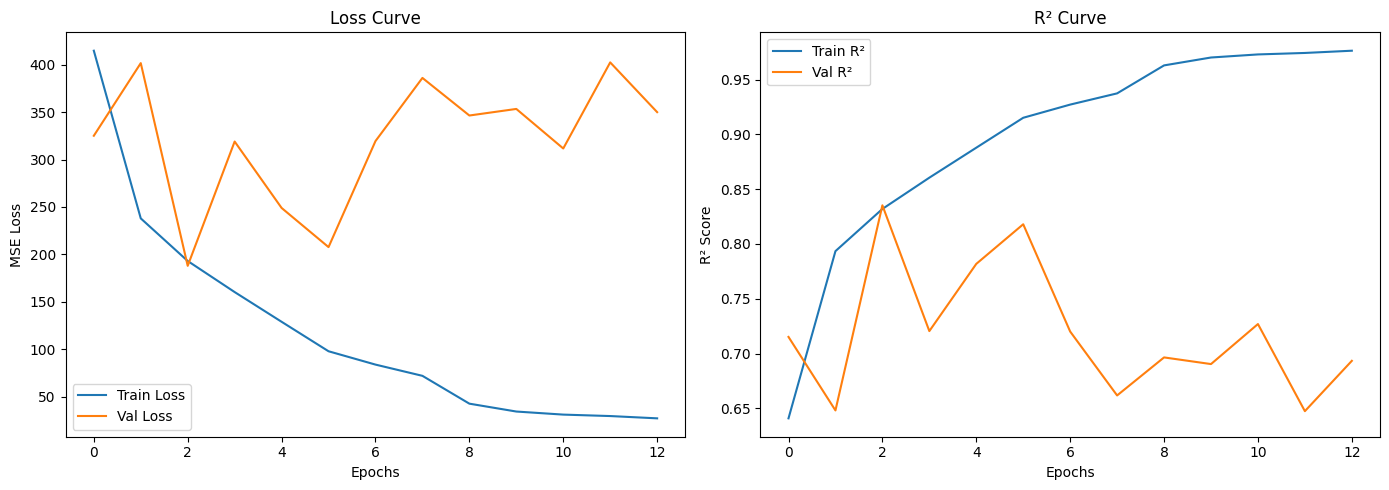

In [15]:
y_pred = vgg16_model.predict(X_val).flatten()

vgg16_mae, vgg16_rmse, vgg16_r2 = evaluate_regression_model(
    y_val,
    y_pred,
    history=vgg16_history,
    model_name="VGG16 "
)


In [16]:
storeResults("VGG16", vgg16_mae, vgg16_rmse, vgg16_r2)

# VGG19

In [17]:
from tensorflow.keras.applications.vgg19 import VGG19

base_model = VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

# Unfreeze last 2 convolution blocks
for layer in base_model.layers:
    if "block5" in layer.name or "block4" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

vgg19_model = Model(inputs=base_model.input, outputs=output)

vgg19_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[R2Metric()]
)

vgg19_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [18]:
vgg19_history = vgg19_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    shuffle=True
)

Epoch 1/100
378/378 [==============================] - 10s 25ms/step - loss: 432.6438 - r2: 0.6252 - val_loss: 236.6248 - val_r2: 0.7927 - lr: 1.0000e-04
Epoch 2/100
378/378 [==============================] - 8s 22ms/step - loss: 270.0936 - r2: 0.7649 - val_loss: 179.8383 - val_r2: 0.8424 - lr: 1.0000e-04
Epoch 3/100
378/378 [==============================] - 8s 22ms/step - loss: 220.6888 - r2: 0.8089 - val_loss: 296.3554 - val_r2: 0.7403 - lr: 1.0000e-04
Epoch 4/100
378/378 [==============================] - 9s 23ms/step - loss: 167.6913 - r2: 0.8539 - val_loss: 249.7088 - val_r2: 0.7812 - lr: 1.0000e-04
Epoch 5/100
378/378 [==============================] - 8s 22ms/step - loss: 158.5130 - r2: 0.8621 - val_loss: 279.2863 - val_r2: 0.7553 - lr: 1.0000e-04
Epoch 6/100
378/378 [==============================] - 8s 22ms/step - loss: 131.7718 - r2: 0.8861 - val_loss: 522.3982 - val_r2: 0.5423 - lr: 1.0000e-04
Epoch 7/100
378/378 [==============================] - 8s 22ms/step - loss: 111.1

In [19]:
vgg19_model.save("Models/vgg19_model.h5")

95/95 [==============================] - 1s 10ms/step

Evaluation Results - VGG19
MAE  : 9.973
RMSE : 13.410
R²   : 0.847


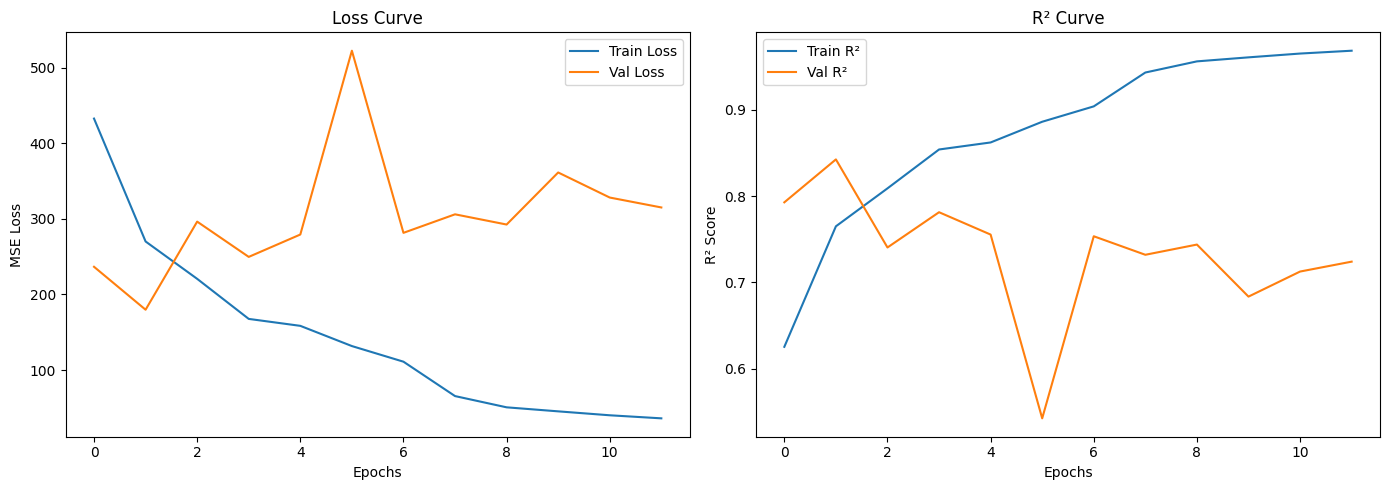

In [20]:
y_pred = vgg19_model.predict(X_val).flatten()

vgg19_mae, vgg19_rmse, vgg19_r2 = evaluate_regression_model(
    y_val,
    y_pred,
    history=vgg19_history,
    model_name="VGG19"
)

In [21]:
storeResults("VGG19", vgg19_mae, vgg19_rmse, vgg19_r2)

# ResNet50

In [22]:
from tensorflow.keras.applications.resnet50 import ResNet50

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

# Fine-tune last convolution stage
for layer in base_model.layers:
    if layer.name.startswith("conv5"):
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

resnet50_model = Model(inputs=base_model.input, outputs=output)

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[R2Metric()]
)

resnet50_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [23]:
resnet50_history = resnet50_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    shuffle=True
)

Epoch 1/100
378/378 [==============================] - 12s 24ms/step - loss: 617.8334 - r2: 0.4628 - val_loss: 355.5287 - val_r2: 0.6885 - lr: 1.0000e-04
Epoch 2/100
378/378 [==============================] - 8s 21ms/step - loss: 193.5673 - r2: 0.8316 - val_loss: 285.2010 - val_r2: 0.7501 - lr: 1.0000e-04
Epoch 3/100
378/378 [==============================] - 8s 21ms/step - loss: 121.0920 - r2: 0.8945 - val_loss: 228.1681 - val_r2: 0.8001 - lr: 1.0000e-04
Epoch 4/100
378/378 [==============================] - 8s 20ms/step - loss: 94.3006 - r2: 0.9182 - val_loss: 191.4373 - val_r2: 0.8323 - lr: 1.0000e-04
Epoch 5/100
378/378 [==============================] - 8s 21ms/step - loss: 75.1080 - r2: 0.9350 - val_loss: 171.9573 - val_r2: 0.8493 - lr: 1.0000e-04
Epoch 6/100
378/378 [==============================] - 7s 20ms/step - loss: 63.9523 - r2: 0.9447 - val_loss: 231.1697 - val_r2: 0.7975 - lr: 1.0000e-04
Epoch 7/100
378/378 [==============================] - 8s 21ms/step - loss: 55.9227 

In [24]:
resnet50_model.save("Models/resnet50_model.h5")

95/95 [==============================] - 2s 11ms/step

Evaluation Results - ResNet50
MAE  : 9.225
RMSE : 13.113
R²   : 0.853


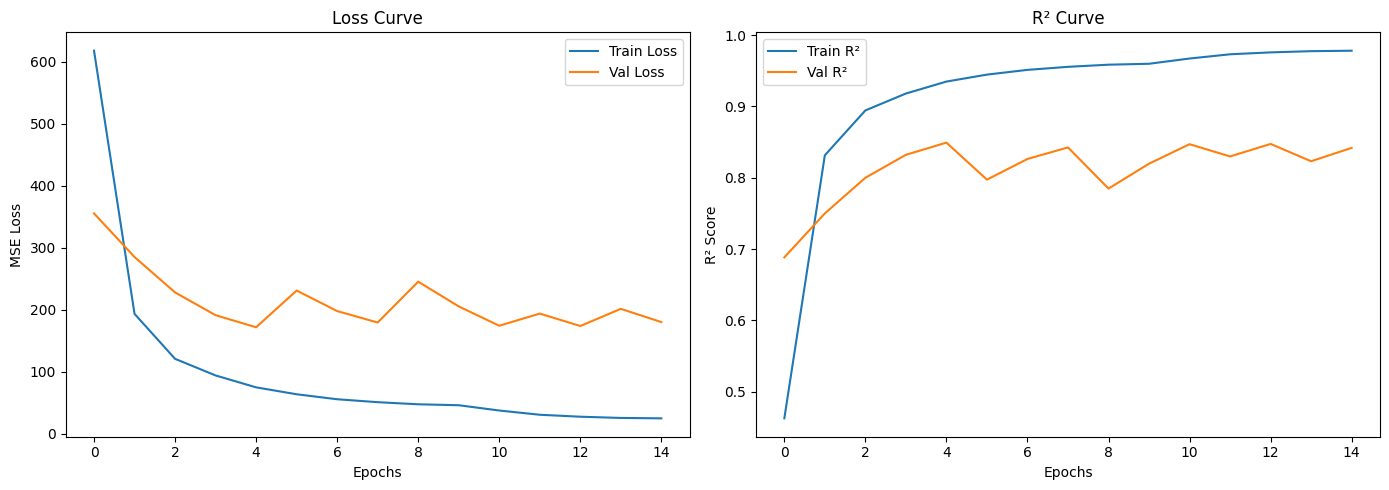

In [25]:
y_pred = resnet50_model.predict(X_val).flatten()

resnet50_mae, resnet50_rmse, resnet50_r2 = evaluate_regression_model(
    y_val,
    y_pred,
    history=resnet50_history,
    model_name="ResNet50"
)

In [26]:
storeResults("ResNet50", resnet50_mae, resnet50_rmse, resnet50_r2)

# Xception

In [27]:
from tensorflow.keras.applications.xception import Xception

base_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

# Fine-tune last convolution blocks
for layer in base_model.layers:
    if "block14" in layer.name or "block13" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

xception_model = Model(inputs=base_model.input, outputs=output)

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[R2Metric()]
)

xception_model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_4[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_2 (Conv2D)              (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [28]:
xception_history = xception_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    shuffle=True
)

Epoch 1/100
378/378 [==============================] - 9s 18ms/step - loss: 1194.9319 - r2: -0.0372 - val_loss: 1748.3864 - val_r2: -0.5319 - lr: 1.0000e-04
Epoch 2/100
378/378 [==============================] - 6s 15ms/step - loss: 548.9785 - r2: 0.5255 - val_loss: 657.5066 - val_r2: 0.4239 - lr: 1.0000e-04
Epoch 3/100
378/378 [==============================] - 5s 14ms/step - loss: 495.0798 - r2: 0.5696 - val_loss: 538.6306 - val_r2: 0.5281 - lr: 1.0000e-04
Epoch 4/100
378/378 [==============================] - 6s 15ms/step - loss: 448.7697 - r2: 0.6120 - val_loss: 458.0934 - val_r2: 0.5986 - lr: 1.0000e-04
Epoch 5/100
378/378 [==============================] - 6s 15ms/step - loss: 426.5397 - r2: 0.6288 - val_loss: 1017.6237 - val_r2: 0.1084 - lr: 1.0000e-04
Epoch 6/100
378/378 [==============================] - 5s 13ms/step - loss: 395.6715 - r2: 0.6563 - val_loss: 1266.4943 - val_r2: -0.1097 - lr: 1.0000e-04
Epoch 7/100
378/378 [==============================] - 6s 15ms/step - loss:

In [29]:
xception_model.save("Models/xception_model.h5")

95/95 [==============================] - 1s 8ms/step

Evaluation Results - Xception
MAE  : 13.376
RMSE : 18.085
R²   : 0.721


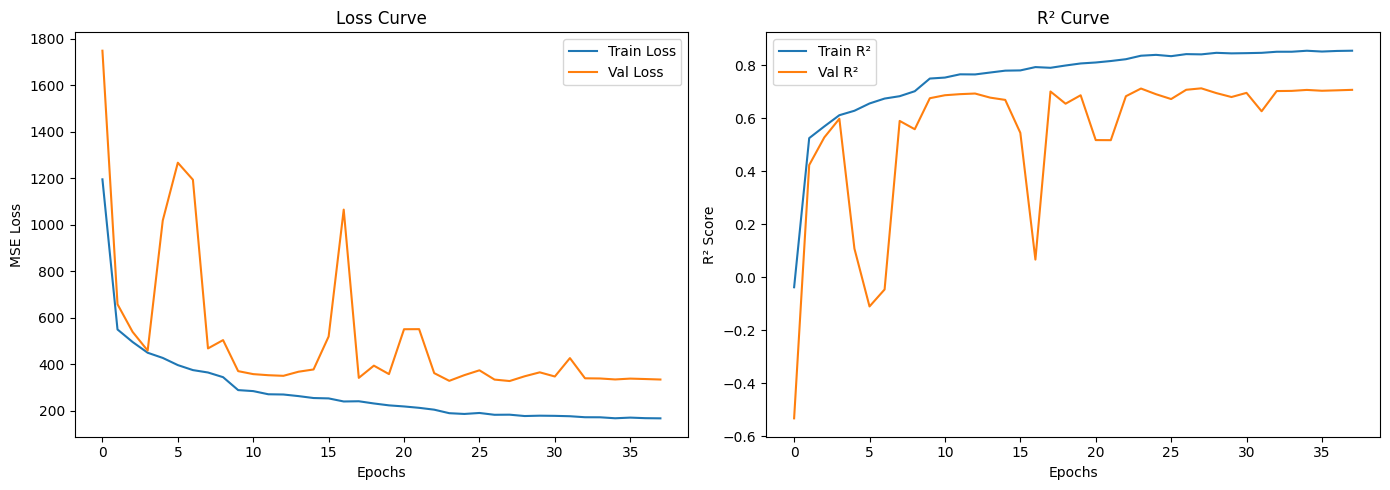

In [30]:
y_pred = xception_model.predict(X_val).flatten()

xception_mae, xception_rmse, xception_r2 = evaluate_regression_model(
    y_val,
    y_pred,
    history=xception_history,
    model_name="Xception"
)

In [31]:
storeResults("Xception", xception_mae, xception_rmse, xception_r2)

# DenseNet121

In [32]:
from tensorflow.keras.applications.densenet import DenseNet121

base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

# Fine-tune last dense block
for layer in base_model.layers:
    if "conv5" in layer.name or "pool5" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

densenet121_model = Model(inputs=base_model.input, outputs=output)

densenet121_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[R2Metric()]
)

densenet121_model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 134, 134, 3)  0          ['input_5[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1/conv[0][0]']       

                                                                                                  
 conv2_block4_1_bn (BatchNormal  (None, 32, 32, 128)  512        ['conv2_block4_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block4_1_relu (Activatio  (None, 32, 32, 128)  0          ['conv2_block4_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block4_2_conv (Conv2D)   (None, 32, 32, 32)   36864       ['conv2_block4_1_relu[0][0]']    
                                                                                                  
 conv2_block4_concat (Concatena  (None, 32, 32, 192)  0          ['conv2_block3_concat[0][0]',    
 te)      

 conv3_block2_1_conv (Conv2D)   (None, 16, 16, 128)  20480       ['conv3_block2_0_relu[0][0]']    
                                                                                                  
 conv3_block2_1_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_1_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block2_1_relu[0][0]']    
                                                                                                  
 conv3_blo

                                                                                                  
 conv3_block6_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block6_1_relu[0][0]']    
                                                                                                  
 conv3_block6_concat (Concatena  (None, 16, 16, 320)  0          ['conv3_block5_concat[0][0]',    
 te)                                                              'conv3_block6_2_conv[0][0]']    
                                                                                                  
 conv3_block7_0_bn (BatchNormal  (None, 16, 16, 320)  1280       ['conv3_block6_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block7_0_relu (Activatio  (None, 16, 16, 320)  0          ['conv3_block7_0_bn[0][0]']      
 n)       

 lization)                                                                                        
                                                                                                  
 conv3_block11_0_relu (Activati  (None, 16, 16, 448)  0          ['conv3_block11_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv3_block11_1_conv (Conv2D)  (None, 16, 16, 128)  57344       ['conv3_block11_0_relu[0][0]']   
                                                                                                  
 conv3_block11_1_bn (BatchNorma  (None, 16, 16, 128)  512        ['conv3_block11_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv3_blo

...

 conv4_block24_concat (Concaten  (None, 8, 8, 1024)  0           ['conv4_block23_concat[0][0]',   
 ate)                                                             'conv4_block24_2_conv[0][0]']   
                                                                                                  
 pool4_bn (BatchNormalization)  (None, 8, 8, 1024)   4096        ['conv4_block24_concat[0][0]']   
                                                                                                  
 pool4_relu (Activation)        (None, 8, 8, 1024)   0           ['pool4_bn[0][0]']               
                                                                                                  
 pool4_conv (Conv2D)            (None, 8, 8, 512)    524288      ['pool4_relu[0][0]']             
                                                                                                  
 pool4_pool (AveragePooling2D)  (None, 4, 4, 512)    0           ['pool4_conv[0][0]']             
          

                                                                                                  
 conv5_block4_concat (Concatena  (None, 4, 4, 640)   0           ['conv5_block3_concat[0][0]',    
 te)                                                              'conv5_block4_2_conv[0][0]']    
                                                                                                  
 conv5_block5_0_bn (BatchNormal  (None, 4, 4, 640)   2560        ['conv5_block4_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block5_0_relu (Activatio  (None, 4, 4, 640)   0           ['conv5_block5_0_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_blo

 conv5_block9_0_relu (Activatio  (None, 4, 4, 768)   0           ['conv5_block9_0_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block9_1_conv (Conv2D)   (None, 4, 4, 128)    98304       ['conv5_block9_0_relu[0][0]']    
                                                                                                  
 conv5_block9_1_bn (BatchNormal  (None, 4, 4, 128)   512         ['conv5_block9_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block9_1_relu (Activatio  (None, 4, 4, 128)   0           ['conv5_block9_1_bn[0][0]']      
 n)                                                                                               
          

                                                                                                  
 conv5_block13_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block13_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block13_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block13_1_relu[0][0]']   
                                                                                                  
 conv5_block13_concat (Concaten  (None, 4, 4, 928)   0           ['conv5_block12_concat[0][0]',   
 ate)                                                             'conv5_block13_2_conv[0][0]']   
                                                                                                  
 conv5_block14_0_bn (BatchNorma  (None, 4, 4, 928)   3712        ['conv5_block13_concat[0][0]']   
 lization)

Total params: 7,332,929
Trainable params: 2,453,505
Non-trainable params: 4,879,424
__________________________________________________________________________________________________


In [33]:
densenet121_history = densenet121_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    shuffle=True
)

Epoch 1/100
378/378 [==============================] - 24s 45ms/step - loss: 929.2211 - r2: 0.1928 - val_loss: 424.6723 - val_r2: 0.6279 - lr: 1.0000e-04
Epoch 2/100
378/378 [==============================] - 15s 39ms/step - loss: 397.4201 - r2: 0.6556 - val_loss: 382.4787 - val_r2: 0.6649 - lr: 1.0000e-04
Epoch 3/100
378/378 [==============================] - 15s 39ms/step - loss: 321.5672 - r2: 0.7207 - val_loss: 376.2575 - val_r2: 0.6703 - lr: 1.0000e-04
Epoch 4/100
378/378 [==============================] - 15s 39ms/step - loss: 275.8696 - r2: 0.7597 - val_loss: 346.3036 - val_r2: 0.6966 - lr: 1.0000e-04
Epoch 5/100
378/378 [==============================] - 15s 39ms/step - loss: 225.9599 - r2: 0.8045 - val_loss: 344.4325 - val_r2: 0.6982 - lr: 1.0000e-04
Epoch 6/100
378/378 [==============================] - 15s 39ms/step - loss: 195.0286 - r2: 0.8311 - val_loss: 336.6455 - val_r2: 0.7050 - lr: 1.0000e-04
Epoch 7/100
378/378 [==============================] - 15s 39ms/step - loss:

In [34]:
densenet121_model.save("Models/densenet121_model.h5")

95/95 [==============================] - 3s 20ms/step

Evaluation Results - DenseNet121
MAE  : 12.289
RMSE : 17.847
R²   : 0.728


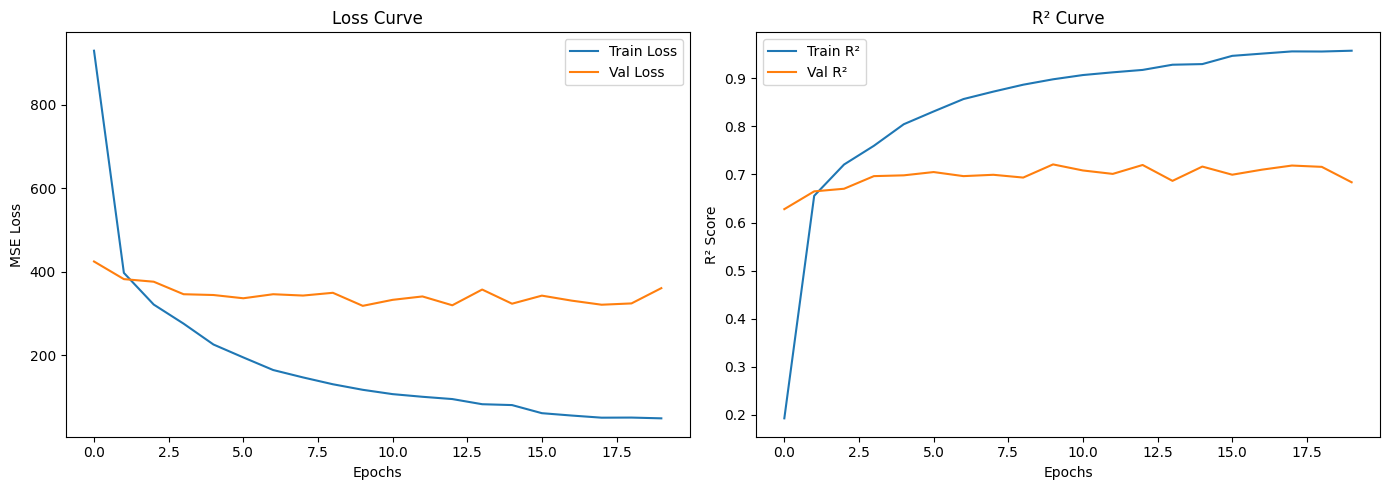

In [35]:
y_pred = densenet121_model.predict(X_val).flatten()

densenet121_mae, densenet121_rmse, densenet121_r2 = evaluate_regression_model(
    y_val,
    y_pred,
    history=densenet121_history,
    model_name="DenseNet121"
)

In [36]:
storeResults("DenseNet121", densenet121_mae, densenet121_rmse, densenet121_r2)

# EfficientNetB0

In [37]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

# Fine-tune last EfficientNet stages
for layer in base_model.layers:
    if "block6" in layer.name or "block7" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

efficientnetb0_model = Model(inputs=base_model.input, outputs=output)

efficientnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[R2Metric()]
)

efficientnetb0_model.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 128, 128, 3)  0           ['input_6[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 128, 128, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 128, 128, 3)  0           ['normalization[0][0]']    

 block2b_expand_conv (Conv2D)   (None, 32, 32, 144)  3456        ['block2a_project_bn[0][0]']     
                                                                                                  
 block2b_expand_bn (BatchNormal  (None, 32, 32, 144)  576        ['block2b_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block2b_expand_activation (Act  (None, 32, 32, 144)  0          ['block2b_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block2b_dwconv (DepthwiseConv2  (None, 32, 32, 144)  1296       ['block2b_expand_activation[0][0]
 D)                                                              ']                               
          

                                                                                                  
 block3b_dwconv (DepthwiseConv2  (None, 16, 16, 240)  6000       ['block3b_expand_activation[0][0]
 D)                                                              ']                               
                                                                                                  
 block3b_bn (BatchNormalization  (None, 16, 16, 240)  960        ['block3b_dwconv[0][0]']         
 )                                                                                                
                                                                                                  
 block3b_activation (Activation  (None, 16, 16, 240)  0          ['block3b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block3b_s

 block4b_activation (Activation  (None, 8, 8, 480)   0           ['block4b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block4b_se_squeeze (GlobalAver  (None, 480)         0           ['block4b_activation[0][0]']     
 agePooling2D)                                                                                    
                                                                                                  
 block4b_se_reshape (Reshape)   (None, 1, 1, 480)    0           ['block4b_se_squeeze[0][0]']     
                                                                                                  
 block4b_se_reduce (Conv2D)     (None, 1, 1, 20)     9620        ['block4b_se_reshape[0][0]']     
                                                                                                  
 block4b_s

                                                                                                  
 block5a_se_reshape (Reshape)   (None, 1, 1, 480)    0           ['block5a_se_squeeze[0][0]']     
                                                                                                  
 block5a_se_reduce (Conv2D)     (None, 1, 1, 20)     9620        ['block5a_se_reshape[0][0]']     
                                                                                                  
 block5a_se_expand (Conv2D)     (None, 1, 1, 480)    10080       ['block5a_se_reduce[0][0]']      
                                                                                                  
 block5a_se_excite (Multiply)   (None, 8, 8, 480)    0           ['block5a_activation[0][0]',     
                                                                  'block5a_se_expand[0][0]']      
                                                                                                  
 block5a_p

 block5c_project_conv (Conv2D)  (None, 8, 8, 112)    75264       ['block5c_se_excite[0][0]']      
                                                                                                  
 block5c_project_bn (BatchNorma  (None, 8, 8, 112)   448         ['block5c_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block5c_drop (Dropout)         (None, 8, 8, 112)    0           ['block5c_project_bn[0][0]']     
                                                                                                  
 block5c_add (Add)              (None, 8, 8, 112)    0           ['block5c_drop[0][0]',           
                                                                  'block5b_add[0][0]']            
                                                                                                  
 block6a_e

 block6b_add (Add)              (None, 4, 4, 192)    0           ['block6b_drop[0][0]',           
                                                                  'block6a_project_bn[0][0]']     
                                                                                                  
 block6c_expand_conv (Conv2D)   (None, 4, 4, 1152)   221184      ['block6b_add[0][0]']            
                                                                                                  
 block6c_expand_bn (BatchNormal  (None, 4, 4, 1152)  4608        ['block6c_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block6c_expand_activation (Act  (None, 4, 4, 1152)  0           ['block6c_expand_bn[0][0]']      
 ivation)                                                                                         
          

 block7a_expand_bn (BatchNormal  (None, 4, 4, 1152)  4608        ['block7a_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block7a_expand_activation (Act  (None, 4, 4, 1152)  0           ['block7a_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block7a_dwconv (DepthwiseConv2  (None, 4, 4, 1152)  10368       ['block7a_expand_activation[0][0]
 D)                                                              ']                               
                                                                                                  
 block7a_bn (BatchNormalization  (None, 4, 4, 1152)  4608        ['block7a_dwconv[0][0]']         
 )        

In [38]:
efficientnetb0_history = efficientnetb0_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    shuffle=True
)

Epoch 1/100
378/378 [==============================] - 18s 31ms/step - loss: 1086.3199 - r2: 0.0563 - val_loss: 372.0424 - val_r2: 0.6740 - lr: 1.0000e-04
Epoch 2/100
378/378 [==============================] - 10s 27ms/step - loss: 371.9072 - r2: 0.6768 - val_loss: 316.9608 - val_r2: 0.7223 - lr: 1.0000e-04
Epoch 3/100
378/378 [==============================] - 10s 26ms/step - loss: 308.2863 - r2: 0.7330 - val_loss: 325.7057 - val_r2: 0.7146 - lr: 1.0000e-04
Epoch 4/100
378/378 [==============================] - 10s 27ms/step - loss: 265.0643 - r2: 0.7700 - val_loss: 282.0407 - val_r2: 0.7529 - lr: 1.0000e-04
Epoch 5/100
378/378 [==============================] - 10s 26ms/step - loss: 232.5731 - r2: 0.7988 - val_loss: 267.9193 - val_r2: 0.7653 - lr: 1.0000e-04
Epoch 6/100
378/378 [==============================] - 10s 27ms/step - loss: 209.9578 - r2: 0.8177 - val_loss: 281.1249 - val_r2: 0.7537 - lr: 1.0000e-04
Epoch 7/100
378/378 [==============================] - 10s 26ms/step - loss

In [41]:
efficientnetb0_model.save_weights("Models/efficientnetb0_weights.h5")

95/95 [==============================] - 2s 12ms/step

Evaluation Results - EfficientNetB0
MAE  : 10.116
RMSE : 14.190
R²   : 0.828


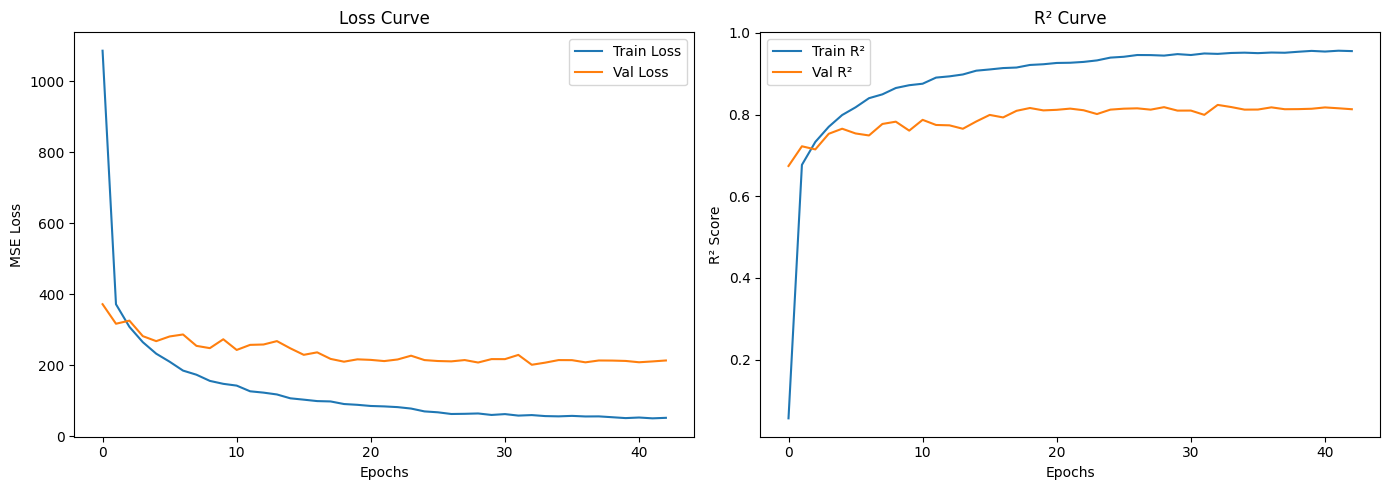

In [42]:
y_pred = efficientnetb0_model.predict(X_val).flatten()

efficientnetb0_mae, efficientnetb0_rmse, efficientnetb0_r2 = evaluate_regression_model(
    y_val,
    y_pred,
    history=efficientnetb0_history,
    model_name="EfficientNetB0"
)

In [43]:
storeResults("EfficientNetB0", efficientnetb0_mae, efficientnetb0_rmse, efficientnetb0_r2)

# Comparison Table

In [44]:
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'MAE'      : mae_l,
                        'RMSE'     : rmse_l,
                        'R² Score' : r2_l                 
                      })

In [45]:
result

,ML Model,MAE,RMSE,R² Score
0,VGG16,10.300,13.711000,0.840
1,VGG19,9.973,13.410000,0.847
2,ResNet50,9.225,13.113000,0.853
3,Xception,13.376,18.084999,0.721
4,DenseNet121,12.289,17.847000,0.728
5,EfficientNetB0,10.116,14.190000,0.828


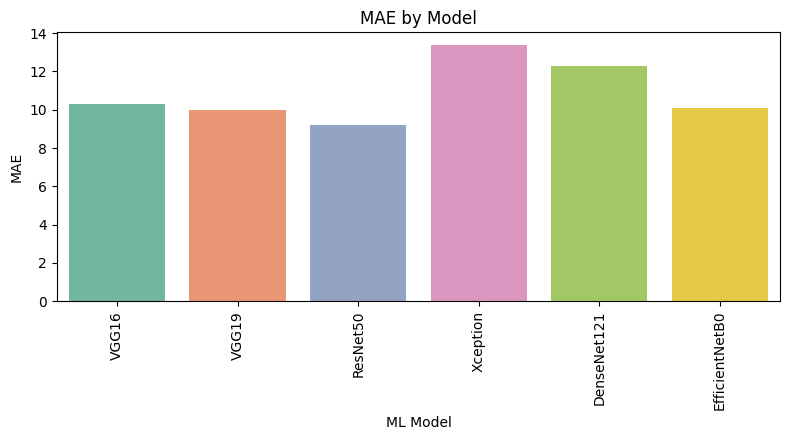

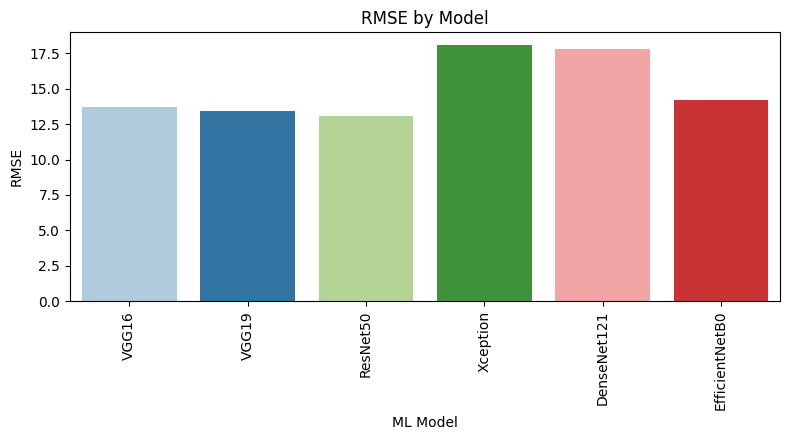

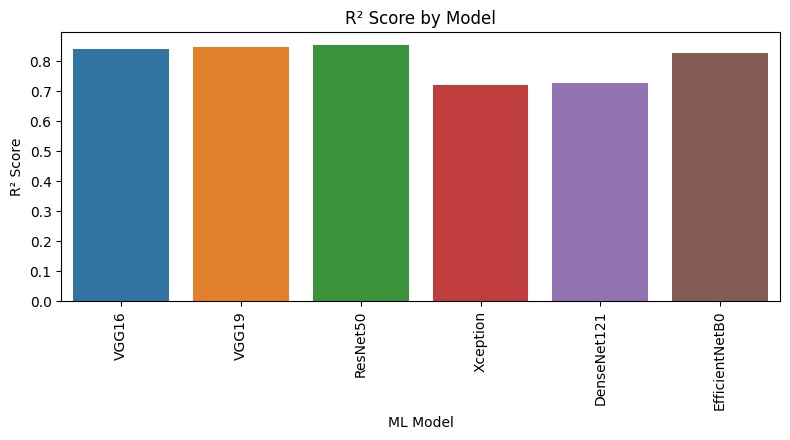

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

for metric, pal in zip(['MAE','RMSE','R² Score'], palettes):
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
